# Experiment Objective

The main objectives of this experiment are:

1. Use the Online Retail dataset from the UCI Machine Learning Repository.
2. Apply the K-Means clustering algorithm to group customers based on purchasing behavior.
3. Visualize the clusters obtained from the algorithm.
4. Display the centroids of each cluster.
5. Compute Cluster Validation Indices (CVIs) to evaluate clustering quality.
6. Use the Elbow Method to determine the optimal number of clusters.

This experiment is essentially a Customer Segmentation problem, where customers with similar purchasing patterns are grouped together.

In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\Raghvendra Goyal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
# The Online Retail dataset (ID 352) is large, containing 541,909 instances.
# The fetch_ucirepo function downloads the entire dataset and parses it into pandas DataFrames,
# which can take several minutes depending on your network speed and system resources.
print(f"Dataset size: {online_retail.metadata.num_instances} rows")
  
# data (as pandas dataframes) 
X = online_retail.data.features 
y = online_retail.data.targets 

# metadata 
print(online_retail.metadata) 
  
# variable information 
print(online_retail.variables) 


Dataset size: 541909 rows
{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM mod

In [18]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\Raghvendra Goyal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Importing Libraries




In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

from sklearn.decomposition import PCA

In [20]:
df = online_retail.data.features

Data Cleaning

In [21]:
df = df.dropna()
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]


Feature Engineering


To analyze the customer behavior, we can calculate the TotalPrice by multiplying the Quantity and UnitPrice.

                   TotalPrice=Quantity×UnitPrice                               

In [22]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

Customer Level Dataset

we are doing customer segmentation on the basis of their purchase history.

                          Group by CustomerID.                               

In [30]:
Customer_data = df.groupby('CustomerID').agg({ 'InvoiceDate': 'nunique', 'Quantity': 'sum', 'UnitPrice': 'mean'})

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Description  397884 non-null  object 
 1   Quantity     397884 non-null  int64  
 2   InvoiceDate  397884 non-null  object 
 3   UnitPrice    397884 non-null  float64
 4   CustomerID   397884 non-null  float64
 5   Country      397884 non-null  object 
 6   TotalPrice   397884 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 24.3+ MB


Rename Columns

In [33]:
Customer_data.columns = ['Transactions','Quantity','TotalSpent']

Customer_data.head()

,Transactions,Quantity,TotalSpent
CustomerID,,,
12346.0,1,74215,1.040000
12347.0,7,2458,2.644011
12348.0,4,2341,5.764839
12349.0,1,631,8.289041
12350.0,1,197,3.841176


In [35]:
Customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Transactions  4338 non-null   int64  
 1   Quantity      4338 non-null   int64  
 2   TotalSpent    4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


Feature Scaling

z = (x - mean(x)) / std(x)

In [37]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(Customer_data)

Elbow Method 

WCSS formula:
                   WCSS = ∑(x−μ)2                               
                   for better understanding of this method pls go at the end of this file

In [38]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

Plotting Elbow

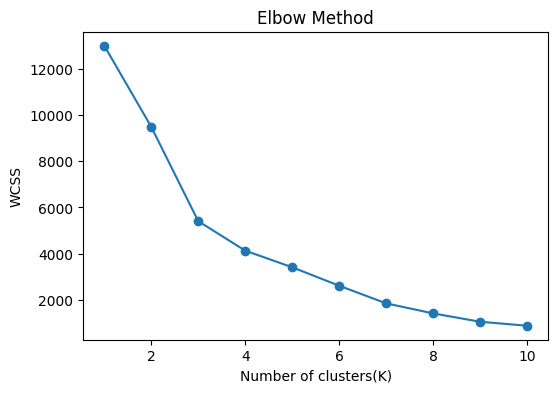

In [39]:
plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters(K)')
plt.ylabel('WCSS')
plt.show()


Choosing 'K' from elbow point method
 USually k = 3 or 4

### K-Means Clustering Concept

K-Means is an unsupervised machine learning algorithm used to divide a dataset into K clusters.

The objective of the algorithm is:To group data points such that items with similar characteristics belong to the same cluster.

In this experiment:Each customer is represented by numerical features.

Customers with similar purchasing behavior are grouped into the same cluster.


### Mathematical Formulation of K-Means

Assume a dataset:
$X = \{x_1, x_2, x_3, \dots, x_n\}$

Each data point is represented as:
$x_i \in \mathbb{R}^d$

Where:
- $n$ = number of data points
- $d$ = number of features

### Step 1: Choose Number of Clusters
Select the number of clusters: $K = 3$. This means the algorithm will divide the dataset into 3 clusters.

### Step 2: Initialize Centroids
Randomly initialize $K$ centroids: $\mu_1, \mu_2, \dots, \mu_k$. Each centroid represents the center of a cluster.

### Step 3: Assignment Step
Each data point is assigned to the nearest centroid using Euclidean distance:
$d(x_i, \mu_j) = \sqrt{\sum_{l=1}^{d} (x_{il} - \mu_{jl})^2}$
Where:
- $x_i$: data point
- $\mu_j$: centroid of cluster $j$

Each point is assigned to the cluster with the minimum distance.

### Step 4: Update Step
After assigning the data points, centroids are recalculated as the mean of all points in the cluster:
$\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i$
Where:
- $C_j$: set of points belonging to cluster $j$
- $|C_j|$: number of data points in cluster $j$

### Step 5: Objective Function
K-Means minimizes the following objective function, known as **Within Cluster Sum of Squares (WCSS)**:
$J = \sum_{j=1}^{K} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$
Lower WCSS indicates better clustering.

# Applying K-Means


In [42]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
Customer_data['Cluster'] = clusters
print(clusters)


[2 0 0 ... 0 0 0]


Centroids

formula: $\mu = \frac{1}{n} \sum_{i=1}^{n} x_i$

In [43]:
centroids = kmeans.cluster_centers_
print("Centroids:", centroids)

Centroids: [[-4.59421611e-02 -5.58607282e-02 -1.36754133e-02]
 [-4.25814720e-01 -2.35911029e-01  5.93037135e+01]
 [ 8.27393148e+00  1.00484680e+01 -1.34023411e-02]]


PCA for Visualization 


In [45]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
Customer_data['PCA1'] = pca_data[:,0]
Customer_data['PCA2'] = pca_data[:,1]

Plotting Clusters

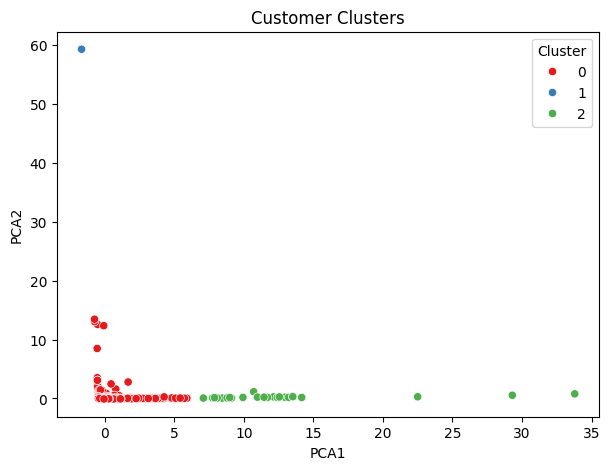

In [47]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x = 'PCA1',
    y = 'PCA2',
    hue = 'Cluster',
    data = Customer_data,
    palette = 'Set1'
)

plt.title("Customer Clusters")

plt.show()

Plotting Centroids
Transform centroids to PCA space.


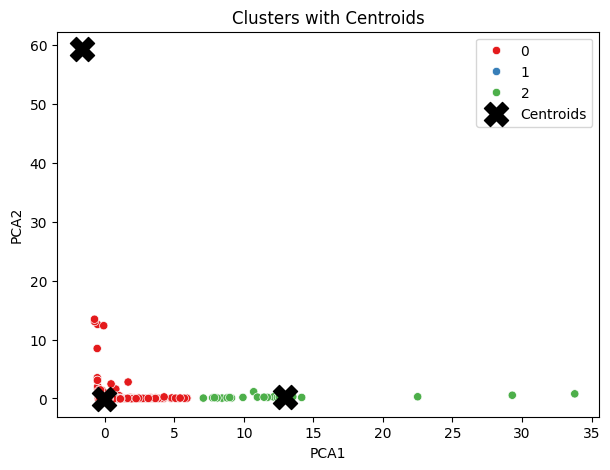

In [48]:
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(7,5))

sns.scatterplot(
    x = 'PCA1',
    y = 'PCA2',
    hue = 'Cluster',
    data = Customer_data,
    palette = 'Set1'
)

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    s = 300,
    c = 'black',
    marker = 'X',
    label = 'Centroids'
)

plt.legend()
plt.title("Clusters with Centroids")
plt.show()

Cluster Validation Indices (3 CVIs)

1. Silhoutte Score  (Range -1 to 1)
2. Davies Bouldin Index  (Lower = Better)
3. Calinski Harabasz Index (Higher = Better)

In [52]:
silhouette = silhouette_score(scaled_data, clusters)
print("Silhouette Score:", silhouette)


Silhouette Score: 0.9498094753503107


In [53]:
db_index = davies_bouldin_score(scaled_data, clusters)
print(db_index)

0.46777120479963036


In [54]:
ch_index = calinski_harabasz_score(scaled_data, clusters)
print("Calinski-Harabasz Index:", ch_index)

Calinski-Harabasz Index: 3049.2692587321794


Final Cluster Distribution

Interpretation:

Cluster 0 -> low spend customers

Cluster 1 -> medium spend customers

Cluster 2 -> high spend customers

In [55]:
Customer_data['Cluster'].value_counts()

Cluster
0    4313
2      24
1       1
Name: count, dtype: int64

### 4. Elbow Method
The Elbow Method helps determine the optimal number of clusters by calculating the Within-Cluster Sum of Squares (WCSS).

**WCSS Formula:**
$WCSS = \sum_{i=1}^{n} (x_i - \mu)^2$

**Procedure:**
1. Run K-Means for different values of $K$.
2. Compute WCSS for each value.
3. Plot a graph: **Number of Clusters (K) vs WCSS**.
4. The optimal value of $K$ is where the graph forms a sharp bend (**elbow point**). At this point, increasing clusters does not significantly reduce WCSS.

---

### 5. Cluster Validation Indices (CVI)
Cluster Validation Indices are used to evaluate the quality of clustering results. In this experiment, we calculate three CVIs:

#### 1. Silhouette Score
Measures how similar a data point is to its own cluster compared to other clusters.

**Formula:**
$S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$

*   $a(i)$: average intra-cluster distance
*   $b(i)$: average distance to the nearest cluster

**Range:** $-1 \le S(i) \le 1$
*   **1**: perfectly clustered
*   **0**: overlapping clusters
*   **-1**: incorrect clustering (Higher value is better)

#### 2. Davies–Bouldin Index
Measures the average similarity between each cluster and its most similar one.

**Formula:**
$DB = \frac{1}{K} \sum_{i=1}^{K} \max_{j \neq i} \left( \frac{S_i + S_j}{M_{ij}} \right)$

*   $S_i$: intra-cluster distance
*   $M_{ij}$: distance between centroids

**Interpretation:** Lower value indicates better clustering performance.

#### 3. Calinski–Harabasz Index
Evaluates the ratio between between-cluster dispersion and within-cluster dispersion.

**Formula:**
$CH = \frac{Tr(B_k)}{Tr(W_k)} \times \frac{n - k}{k - 1}$

*   $Tr(B_k)$: between-cluster variance
*   $Tr(W_k)$: within-cluster variance
*   $n$: number of samples, $k$: number of clusters

**Interpretation:** Higher value indicates better cluster separation.

---

### Summary of Validation Metrics
| Metric | Goal |
| :--- | :--- |
| **Silhouette Score** | Higher is better |
| **Davies–Bouldin Index** | Lower is better |
| **Calinski–Harabasz Index** | Higher is better |


### Must-Know Concepts

*   **Why K-Means?**  
    An efficient unsupervised algorithm used for clustering data points.
*   **Why PCA?**  
    Used for dimensionality reduction to visualize high-dimensional data in 2D.
*   **Why CVIs (Cluster Validity Indices)?**  
    Used to evaluate and validate the quality of the clustering results.
*   **Why Elbow Method?**  
    A heuristic used to determine the optimal number of clusters ($K$).
